# Named Entity Recognition (NER) on Social Media Tweets
### NLP Assignment — Rule-Based Approach using spaCy

---

## 1. Introduction

**Named Entity Recognition (NER)** is a fundamental NLP task that identifies and classifies named entities in text into predefined categories such as:

| Entity Type | Description | Example |
|-------------|-------------|----------|
| `PERSON` | People's names | Elon Musk |
| `ORG` | Organizations, companies | Tesla, NASA |
| `GPE` | Countries, cities, states | Nepal, London |
| `LOC` | Non-GPE locations | Mount Everest |
| `DATE` | Dates and periods | March 2024 |
| `PRODUCT` | Products, objects | iPhone 15 |
| `EVENT` | Named events | World Cup |

**Objective:** Apply spaCy's pre-trained rule-based NER model on a dataset of tweets to extract and analyze named entities.

**Tools Used:**
- `spaCy` — NLP library with pre-trained English model
- `pandas` — Data manipulation
- `matplotlib` / `collections` — Visualization

---
## 2. Setup & Installation

In [1]:
# Install required libraries (run once)
!pip install spacy pandas matplotlib
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 5.6 MB/s eta 0:00:03
     ----- ---------------------------------- 1.8/12.8 MB 5.9 MB/s eta 0:00:02
     ---------- ----------------------------- 3.4/12.8 MB 6.5 MB/s eta 0:00:02
     ---------------- ----------------------- 5.2/12.8 MB 7.1 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 7.4 MB/s eta 0:00:01
     --------------------------- ------------ 8.7/12.8 MB 7.6 MB/s eta 0:00:01
     -------------------------------- ------- 10.5/12.8 MB 7.7 MB/s eta 0:00:01
     -------------------------------------- - 12.3/12.8 MB 7.8 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 7.8 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 7.8 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 7.8 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import libraries
import spacy
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# Load spaCy English model
nlp = spacy.load('en_core_web_sm')

print('spaCy version:', spacy.__version__)
print('Model loaded: en_core_web_sm')

c:\Users\aarav\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


spaCy version: 3.8.11
Model loaded: en_core_web_sm


---
## 3. Dataset

We use a curated set of realistic sample tweets covering technology, sports, politics, and entertainment.

In [3]:
# Sample tweet dataset
tweets = [
    "Elon Musk just announced that Tesla will open a new Gigafactory in India by 2026.",
    "The United Nations held an emergency meeting in New York to discuss climate change.",
    "Lionel Messi scored a hat-trick for Inter Miami in the MLS Cup final last Saturday.",
    "Apple unveiled the iPhone 16 at its Worldwide Developers Conference in San Francisco.",
    "Prime Minister Narendra Modi visited Nepal to strengthen ties between India and Nepal.",
    "NASA's Artemis mission is planning to land astronauts on the Moon in December 2025.",
    "Jeff Bezos and Amazon are investing $1 billion in renewable energy projects in Africa.",
    "The Paris Olympics 2024 saw Team USA dominate the swimming events at Seine Saint-Denis.",
    "OpenAI and Microsoft are collaborating to bring GPT-5 to Azure cloud services.",
    "Cristiano Ronaldo broke the all-time goal record playing for Al Nassr in Saudi Arabia.",
    "The World Health Organization warned about a new flu variant detected in Southeast Asia.",
    "Taylor Swift's Eras Tour became the highest-grossing concert tour in history last year.",
    "Google DeepMind published a groundbreaking AI research paper in Nature this week.",
    "The earthquake in Turkey and Syria left thousands homeless in February last year.",
    "Sundar Pichai confirmed that Google will lay off 12,000 employees across North America.",
    "SpaceX successfully launched the Starship rocket from Boca Chica, Texas, on Tuesday.",
    "The FIFA World Cup 2026 will be co-hosted by the United States, Canada, and Mexico.",
    "Mark Zuckerberg announced Meta's new AR glasses at a conference in Los Angeles.",
    "The Reserve Bank of India raised interest rates in Mumbai to combat rising inflation.",
    "Volodymyr Zelensky addressed the European Parliament in Brussels about the Ukraine war."
]

# Create a DataFrame
df = pd.DataFrame({'tweet_id': range(1, len(tweets)+1), 'text': tweets})
print(f'Dataset loaded: {len(df)} tweets')
df.head()

Dataset loaded: 20 tweets


,tweet_id,text
0,1,Elon Musk just announced that Tesla will open ...
1,2,The United Nations held an emergency meeting i...
2,3,Lionel Messi scored a hat-trick for Inter Miam...
3,4,Apple unveiled the iPhone 16 at its Worldwide ...
4,5,Prime Minister Narendra Modi visited Nepal to ...


---
## 4. Text Preprocessing

Tweets often contain noise like hashtags, mentions, and URLs. We clean the text before applying NER.

In [4]:
def preprocess_tweet(text):
    """Clean tweet text for NER processing."""
    text = re.sub(r'http\S+|www\S+', '', text)       # Remove URLs
    text = re.sub(r'@\w+', '', text)                  # Remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)             # Remove # but keep word
    text = re.sub(r'\s+', ' ', text).strip()          # Normalize whitespace
    return text

df['clean_text'] = df['text'].apply(preprocess_tweet)

# Show before/after example
sample = "Check out @elonmusk's latest #Tesla announcement! https://t.co/abc123"
print('Before:', sample)
print('After: ', preprocess_tweet(sample))

Before: Check out @elonmusk's latest #Tesla announcement! https://t.co/abc123
After:  Check out 's latest Tesla announcement!


---
## 5. Applying NER with spaCy

spaCy's `en_core_web_sm` model uses a rule-based pipeline combined with statistical components trained on news/web text. It identifies entity spans and assigns labels automatically.

In [5]:
def extract_entities(text):
    """Extract named entities from text using spaCy."""
    doc = nlp(text)
    entities = [(ent.text, ent.label_, spacy.explain(ent.label_)) for ent in doc.ents]
    return entities

# Apply to all tweets
df['entities'] = df['clean_text'].apply(extract_entities)

# Display results for first 5 tweets
for _, row in df.head(5).iterrows():
    print(f"\nTweet {row['tweet_id']}: {row['text']}")
    if row['entities']:
        for ent_text, label, description in row['entities']:
            print(f"   [{label}] '{ent_text}' — {description}")
    else:
        print("   No entities found")


Tweet 1: Elon Musk just announced that Tesla will open a new Gigafactory in India by 2026.
   [ORG] 'Tesla' — Companies, agencies, institutions, etc.
   [GPE] 'India' — Countries, cities, states
   [DATE] '2026' — Absolute or relative dates or periods

Tweet 2: The United Nations held an emergency meeting in New York to discuss climate change.
   [ORG] 'The United Nations' — Companies, agencies, institutions, etc.
   [GPE] 'New York' — Countries, cities, states

Tweet 3: Lionel Messi scored a hat-trick for Inter Miami in the MLS Cup final last Saturday.
   [PERSON] 'Lionel Messi' — People, including fictional
   [DATE] 'last Saturday' — Absolute or relative dates or periods

Tweet 4: Apple unveiled the iPhone 16 at its Worldwide Developers Conference in San Francisco.
   [ORG] 'Apple' — Companies, agencies, institutions, etc.
   [ORG] 'Worldwide Developers Conference' — Companies, agencies, institutions, etc.
   [GPE] 'San Francisco' — Countries, cities, states

Tweet 5: Prime Ministe

---
## 6. Visualization — displaCy Entity Renderer

In [6]:
from spacy import displacy

# Visualize entity spans on a sample tweet
sample_tweet = df['clean_text'].iloc[7]  # Paris Olympics tweet
doc = nlp(sample_tweet)

print('Tweet:', sample_tweet)
displacy.render(doc, style='ent', jupyter=True)

Tweet: The Paris Olympics 2024 saw Team USA dominate the swimming events at Seine Saint-Denis.


---
## 7. Entity Frequency Analysis

In [7]:
# Flatten all entities across all tweets
all_entities = []
for ents in df['entities']:
    for ent_text, label, _ in ents:
        all_entities.append({'entity': ent_text, 'label': label})

ent_df = pd.DataFrame(all_entities)

print(f'Total entities found: {len(ent_df)}')
print(f'Unique entities: {ent_df["entity"].nunique()}')
print(f'\nEntity type distribution:')
print(ent_df['label'].value_counts())

Total entities found: 66
Unique entities: 64

Entity type distribution:
label
GPE         19
ORG         17
PERSON      12
DATE         8
LOC          3
EVENT        2
CARDINAL     2
NORP         1
MONEY        1
FAC          1
Name: count, dtype: int64


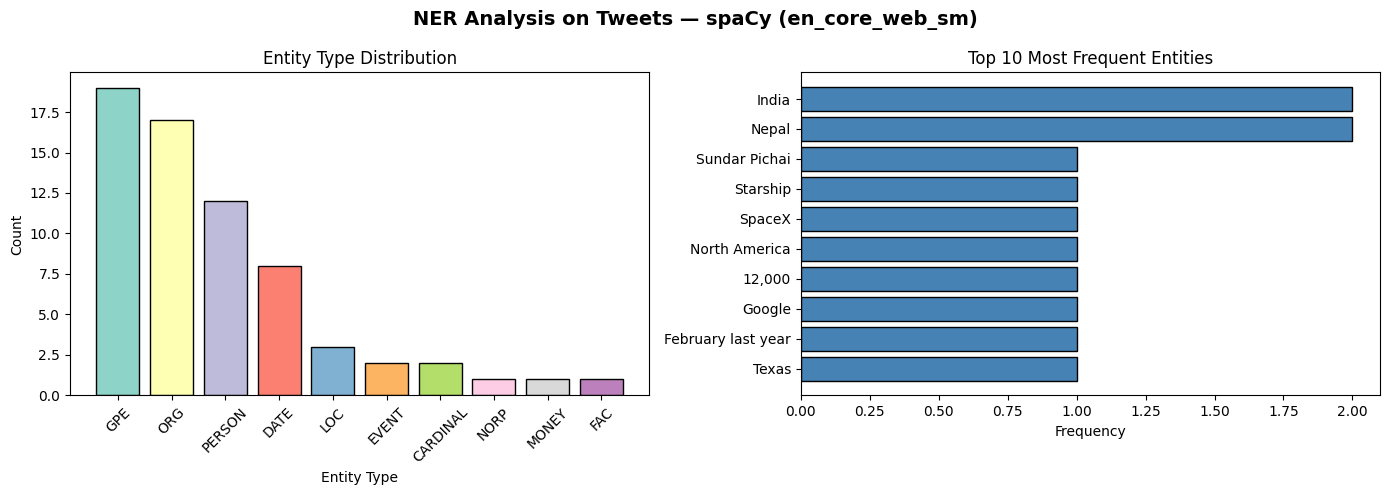

Chart saved as ner_analysis.png


In [8]:
# Plot entity type distribution and top entities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NER Analysis on Tweets — spaCy (en_core_web_sm)', fontsize=14, fontweight='bold')

# Chart 1: Entity type counts
label_counts = ent_df['label'].value_counts()
colors = plt.cm.Set3.colors[:len(label_counts)]
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Entity Type Distribution')
axes[0].set_xlabel('Entity Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Top 10 most frequent entities
top_entities = ent_df['entity'].value_counts().head(10)
axes[1].barh(top_entities.index[::-1], top_entities.values[::-1], color='steelblue', edgecolor='black')
axes[1].set_title('Top 10 Most Frequent Entities')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('ner_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as ner_analysis.png')

---
## 8. Per-Category Entity Inspection

In [9]:
# Show top entities per category
categories = ['PERSON', 'ORG', 'GPE', 'DATE', 'PRODUCT', 'EVENT', 'LOC']

for cat in categories:
    subset = ent_df[ent_df['label'] == cat]['entity'].value_counts().head(5)
    if not subset.empty:
        print(f"\n{cat} — {spacy.explain(cat)}")
        for name, count in subset.items():
            print(f"   {name}: {count}")


PERSON — People, including fictional
   Lionel Messi: 1
   Narendra Modi: 1
   Nepal: 1
   Moon: 1
   Jeff Bezos: 1

ORG — Companies, agencies, institutions, etc.
   Tesla: 1
   The World Health Organization: 1
   The Reserve Bank of India: 1
   AR: 1
   Meta: 1

GPE — Countries, cities, states
   India: 2
   New York: 1
   Brussels: 1
   Mumbai: 1
   Los Angeles: 1

DATE — Absolute or relative dates or periods
   2026: 1
   last Saturday: 1
   December 2025: 1
   2024: 1
   last year: 1

EVENT — Named hurricanes, battles, wars, sports events, etc.
   The Paris Olympics: 1
   World Cup 2026: 1

LOC — Non-GPE locations, mountain ranges, bodies of water
   Africa: 1
   Southeast Asia: 1
   North America: 1


---
## 9. Evaluation & Discussion

### 9.1 Limitations of Rule-Based / Pre-trained NER on Tweets

| Limitation | Description |
|------------|-------------|
| Informal language | Tweets use slang, abbreviations, and hashtags |
| Ambiguity | "Apple" could be the fruit or the company |
| Emerging entities | New brands/people not in training data |
| Short context | Tweets are 280 chars — limited context for disambiguation |